# Data Preparation
Reusable functions for static (landscape) and dynamic (perimeter/weather) data preparation. The parameters that the user should define are:

1. Incident name
2. Ignition longitude
3. Ignition latitude
4. Radius in miles (for the initial bounding box)
5. Landscape filepath (e.g., ```landscape.lcp```)

This notebook defines functions for each data preparation step, then demonstrates them with the BORDER 2 fire as an example.

In [1]:
import sys
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import json
import geojson
from datetime import datetime
import time
from pathlib import Path
from shapely.geometry import box, Point, Polygon
import matplotlib.pyplot as plt
from pyproj import Transformer

import zipfile
from osgeo import gdal, osr
import io
import subprocess
import shapely
from io import StringIO

import contextily as ctx

from config import *
from firemap import *

# Enable GDAL exceptions
gdal.UseExceptions()
osr.UseExceptions()

# Synthetic Fire Example

## 1. Define Fire Parameters

In [2]:
# BORDER 2 fire parameters
FIRE_NAME = "Border 2 Synthetic"
IGNITION_LON = -116.88  # Approximate ignition point
IGNITION_LAT = 32.61
IGNITION_DATE = "2025-01-23"
RADIUS_KM = 10  # Bounding box radius
LCP_PATH = "landscape.lcp"  # Path to landscape file

print(f"Configuration:")
print(f"  Fire name: {FIRE_NAME}")
print(f"  Ignition point: ({IGNITION_LAT}, {IGNITION_LON})")
print(f"  Ignition date: {IGNITION_DATE}")
print(f"  Domain radius: {RADIUS_KM} km")
print(f"  Landscape file: {LCP_PATH}")



Configuration:
  Fire name: Border 2 Synthetic
  Ignition point: (32.61, -116.88)
  Ignition date: 2025-01-23
  Domain radius: 10 km
  Landscape file: landscape.lcp


## 2. Retrieve Satellite Fire Detections

In [3]:
# Define bounding box around ignition point
bbox_gdf = create_bbox_from_point(
    lon=IGNITION_LON,
    lat=IGNITION_LAT,
    radius_km=RADIUS_KM,
    write_geojson=True,
    output_path=OUTPUT_DIR / "border_2_synthetic_initial_bbox.geojson"
)
bbox = bbox_gdf.total_bounds
print(f"\nBounding box bounds (EPSG:4326): {bbox}")


# Retrieve active fire detections from NASA satellites
hotspots_gdf = get_fire_detections(bbox, IGNITION_DATE, day_range=1)

✓ Bounding box saved to /home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/outputs/border_2_synthetic_initial_bbox.geojson

Bounding box bounds (EPSG:4326): [-116.98658176   32.51979014 -116.77341878   32.70020856]

NASA FIRMS Satellite Response: https://firms.modaps.eosdis.nasa.gov/usfs/api/area/csv/b38da98e9b7e9389fd05a00c32f99783/LANDSAT_NRT/-116.9865817551599,32.51979014029865,-116.77341878208908,32.70020856190265/1/2025-01-23

✓ Retrieved 4 fire detections

Data columns:
['latitude', 'longitude', 'path', 'row', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'confidence', 'daynight']


✓ Basemap added


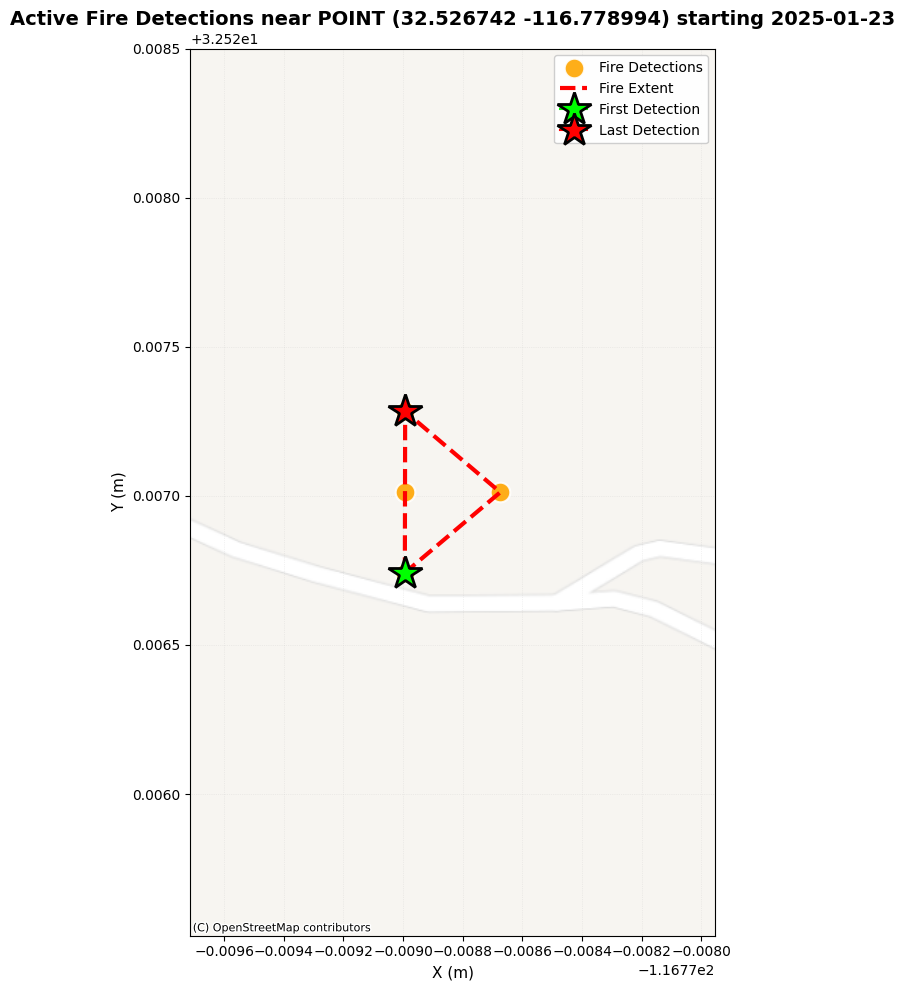

In [4]:
plot_active_hotspots(hotspots_gdf)

In [5]:
IGNITION_POLY = hotspots_gdf.union_all().convex_hull
list(IGNITION_POLY.bounds)

[-116.778994, 32.526742, -116.778674, 32.527283]

## 3. Verify Landscape File

In [6]:
# Check if landscape file exists
lcp_exists = verify_landscape_file(LCP_PATH)

✗ Landscape file not found: landscape.lcp
You need to generate or download a .lcp file for your domain.
See FARSITE documentation for landscape file creation.


In [7]:
# Generate landscape file if necessary
landfire_data = download_landfire_data(
                poly=IGNITION_POLY,
                output_dir=DATA_DIR / "landfire",
                email="tcaglar@ucsd.edu")

Generating new .lcp file for FARSITE...
To use an existing .lcp file instead, call: verify_landscape_file(LCP_PATH)
Area of Interest: ((-117.2789931458299, 32.14459625824527, -116.45495382577731, 32.908341064868374))

Submitting LANDFIRE request...
✓ Job ID: d961b03b-b17d-4f41-9fd0-673ef0451118
  Notification will be sent to tcaglar@ucsd.edu

LFPS Job Status URL: https://lfps.usgs.gov/api/job/status?JobId=d961b03b-b17d-4f41-9fd0-673ef0451118

Waiting for LANDFIRE processing (takes a couple minutes)...
  [0s] pending
  [11s] executing
  [21s] succeeded

✓ Completed in 21s
Downloading...
Extracting...

Converting j117a14f95b494dab8ac6aff4187de66b.tif to ASCII rasters...


Warning 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed
Warning 1: The definition of projected CRS EPSG:5070 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.


  ✓ 250CBD.asc


Warning 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed
Warning 1: The definition of projected CRS EPSG:5070 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.


  ✓ 250CBH.asc


...

Warning 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed
Warning 1: The definition of projected CRS EPSG:5070 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.


  ✓ ASP2020.asc


Warning 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed
Warning 1: The definition of projected CRS EPSG:5070 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.


  ✓ ELEV2020.asc
  ✓ SLPP2020.asc

✓ LANDFIRE data downloaded to /home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/data/landfire/


Warning 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed
Warning 1: The definition of projected CRS EPSG:5070 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.


In [8]:
landfire_data

{'elevation': PosixPath('/home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/data/landfire/ELEV2020.asc'),
 'slope': PosixPath('/home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/data/landfire/SLPP2020.asc'),
 'aspect': PosixPath('/home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/data/landfire/ASP2020.asc'),
 'fuel': PosixPath('/home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/data/landfire/250FBFM40.asc'),
 'canopy_cover': PosixPath('/home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/data/landfire/250CC.asc'),
 'canopy_height': PosixPath('/home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/data/landfire/250CH.asc'),
 'canopy_base': PosixPath('/home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/data/landfire/250CBH.asc'),
 'canopy_density': PosixPath('/home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/data/landfire/250CBD.asc')}

In [9]:
lcp_path_returned = generate_lcp_from_rasters(
                    output_path=LCP_PATH,
                    elevation_asc=landfire_data['elevation'],
                    slope_asc=landfire_data['slope'],
                    aspect_asc=landfire_data['aspect'],
                    fuel_asc=landfire_data['fuel'],
                    canopy_cover_asc=landfire_data['canopy_cover'],
                    canopy_height_asc=landfire_data['canopy_height'],
                    canopy_base_asc=landfire_data['canopy_base'],
                    canopy_density_asc=landfire_data['canopy_density'],
                    latitude=IGNITION_LAT
)


Running lcpmake command:
/home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/src/lcpmake -latitude 32.61 -landscape landscape -elevation /home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/data/landfire/ELEV2020.asc -slope /home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/data/landfire/SLPP2020.asc -aspect /home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/data/landfire/ASP2020.asc -fuel /home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/data/landfire/250FBFM40.asc -cover /home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/data/landfire/250CC.asc -height /home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/data/landfire/250CH.asc -base /home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/data/landfire/250CBH.asc -density /home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/data/landfire/250CBD.asc -fb40

✓ Landscape file created: landscape.lcp
  Size: 18163.0 KB


## 4. Fetch Fire Perimeters

In [10]:
# ── Fetch perimeters from WIFIRE Firemap ──────────────────────────────────
# FIRE_NAME = "BORDER 2"
# YEAR = 2025

perimeters_gdf = fetch_fire_perimeters(fire_name=FIRE_NAME,
                                       geoserver_layer='WIFIRE:synthetic_fire_perimeters',
                                       verbose=True)

# ── Verify time progression ───────────────────────────────────────────────
print(f"\nTime progression check:")
for i in range(len(perimeters_gdf)):
    row = perimeters_gdf.iloc[i]
    print(f"  [{i}] {row['datetime'].date()}  —  {row.geometry.area/1e6:.2f} km²")

diffs = perimeters_gdf['datetime'].diff().dropna()
print(f"\nTime deltas between perimeters:")
for i, d in enumerate(diffs):
    print(f"  [{i}→{i+1}] {d}")

# ── Save perimeters ───────────────────────────────────────────────────────
perimeters_path = OUTPUT_DIR / f"{FIRE_NAME.lower().replace(' ', '_')}_perimeters.geojson"

# GeoJSON doesn't support timezone-aware datetimes — strip tz before saving
save_gdf = perimeters_gdf.copy()
save_gdf['datetime'] = save_gdf['datetime'].dt.strftime('%Y-%m-%dT%H:%M:%S')

save_gdf.to_file(perimeters_path, driver="GeoJSON")
print(f"\n✓ Saved {len(perimeters_gdf)} perimeters to {perimeters_path}")

Fetching perimeters for 'Border 2 Synthetic' (2025)...


/home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/src/firemap.py:78: UserWarning: The 'year' parameter is currently not used for filtering perimeters. Ensure the fire name is unique or includes the year if needed.
  warnings.warn(


  Retrieved 13 perimeter(s)

✓ 13 perimeters ready
  Oldest: 2025-01-24 13:00:00
  Newest: 2025-01-25 01:00:00
  Area range: 0.04 – 55.94 km²

  Perimeter timeline:
    [0] 2025-01-24  —  0.04 km²  
    [1] 2025-01-24  —  0.38 km²  
    [2] 2025-01-24  —  0.94 km²  
    [3] 2025-01-24  —  2.03 km²  
    [4] 2025-01-24  —  3.49 km²  
    [5] 2025-01-24  —  5.74 km²  
    [6] 2025-01-24  —  9.00 km²  
    [7] 2025-01-24  —  13.72 km²  
    [8] 2025-01-24  —  21.99 km²  
    [9] 2025-01-24  —  31.39 km²  
    [10] 2025-01-24  —  39.84 km²  
    [11] 2025-01-25  —  49.62 km²  
    [12] 2025-01-25  —  55.94 km²  

Time progression check:
  [0] 2025-01-24  —  0.04 km²
  [1] 2025-01-24  —  0.38 km²
  [2] 2025-01-24  —  0.94 km²
  [3] 2025-01-24  —  2.03 km²
  [4] 2025-01-24  —  3.49 km²
  [5] 2025-01-24  —  5.74 km²
  [6] 2025-01-24  —  9.00 km²
  [7] 2025-01-24  —  13.72 km²
  [8] 2025-01-24  —  21.99 km²
  [9] 2025-01-24  —  31.39 km²
  [10] 2025-01-24  —  39.84 km²
  [11] 2025-01-25  —  49

## 5. Extract Fire Timeline

In [11]:
# Get ignition and containment dates
timeline = extract_fire_timeline(perimeters_gdf, verbose=True)


Fire Timeline:
  First observation (ignition): 2025-01-24 13:00:00
  Last observation (containment): 2025-01-25 01:00:00
  Total duration: 0 days 12:00:00
  Number of updates: 13


## 6. Visualize Perimeter Evolution

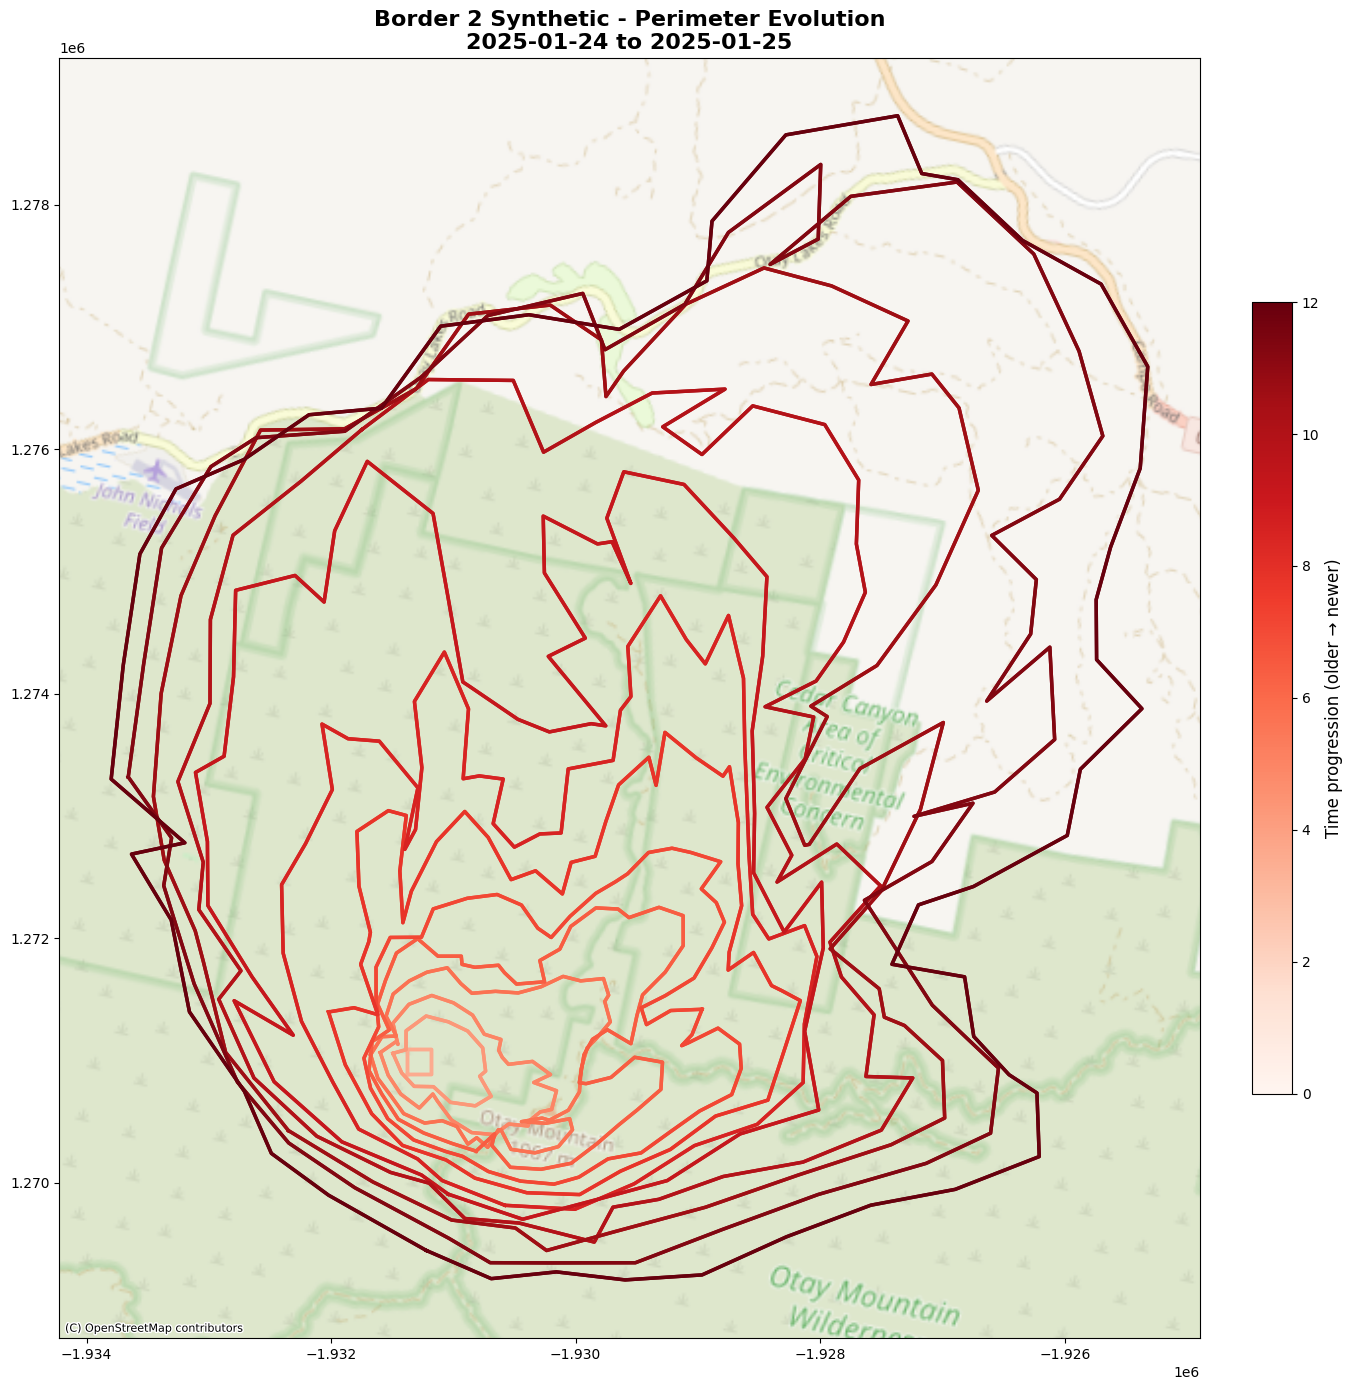

In [12]:
# Plot fire growth over time
plot_perimeter_evolution(perimeters_gdf, fire_name=FIRE_NAME)

## 7. Fetch Weather Data

In [13]:
# Get weather station location from fire centroid
wx_lat, wx_lon = get_weather_location_from_fire(perimeters_gdf, to_wgs84=True)

print(f"Weather query location: {wx_lat:.4f}, {wx_lon:.4f}")

Weather query location: 32.5959, -116.8571


In [14]:
# Fetch weather for entire fire duration
weather_data = fetch_weather_data(
    lat=wx_lat,
    lon=wx_lon,
    start_time=timeline['ignition_date'],
    end_time=timeline['containment_date'],
    verbose=True
)

Querying weather data...
  Location: 32.5959, -116.8571
  From: 2025-01-24T13:00:00
  To: 2025-01-25T01:00:00

✓ Retrieved 59 weather observations
  Wind speed: 0.8 - 10.4 mph (mean: 5.0)
  Wind direction: 62 - 255° (mean: 131)


## 8. Visualize Weather Data

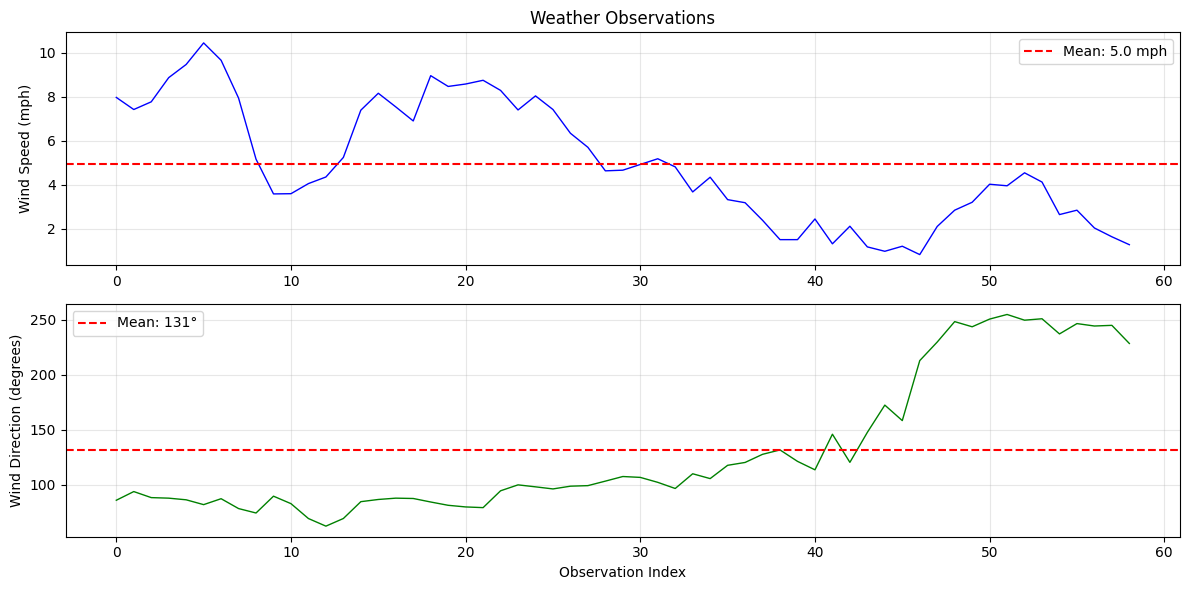

In [15]:
# Plot weather observations
plot_weather_data(weather_data)

## 9. Save All Data

In [16]:
YEAR = 2025

# ── Extract timeline ──────────────────────────────────────────────────────
ignition_date    = perimeters_gdf['datetime'].iloc[0]
containment_date = perimeters_gdf['datetime'].iloc[-1]
duration_days    = (containment_date - ignition_date).days

print(f"Ignition:    {ignition_date}")
print(f"Containment: {containment_date}")
print(f"Duration:    {duration_days} days")

# ── Get weather query location (centroid of first perimeter in WGS84) ─────
first_perim_wgs84 = perimeters_gdf.iloc[[0]].to_crs("EPSG:4326")
centroid = first_perim_wgs84.geometry.centroid.iloc[0]
wx_lat, wx_lon = centroid.y, centroid.x

# ── Save config ───────────────────────────────────────────────────────────
workflow_config = {
    "fire_name":         FIRE_NAME,
    "year":              YEAR,
    "lcp_path":          str(LCP_PATH),
    "ignition_date":     ignition_date.isoformat(),
    "containment_date":  containment_date.isoformat(),
    "duration_days":     duration_days,
    "n_perimeters":      len(perimeters_gdf),
    "perimeters_path":   str(perimeters_path),
    "weather_location":  {"lat": wx_lat, "lon": wx_lon},
    "data_source":       "WIFIRE Firemap WFS (view_historical_fires)"
}

config_path = DATA_DIR / "workflow_config.json"
with open(config_path, 'w') as f:
    json.dump(workflow_config, f, indent=2)

print(f"✓ Config saved to {config_path}")
print(json.dumps(workflow_config, indent=2))

Ignition:    2025-01-24 13:00:00
Containment: 2025-01-25 01:00:00
Duration:    0 days
✓ Config saved to /home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/data/workflow_config.json
{
  "fire_name": "Border 2 Synthetic",
  "year": 2025,
  "lcp_path": "landscape.lcp",
  "ignition_date": "2025-01-24T13:00:00",
  "containment_date": "2025-01-25T01:00:00",
  "duration_days": 0,
  "n_perimeters": 13,
  "perimeters_path": "/home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/outputs/border_2_synthetic_perimeters.geojson",
  "weather_location": {
    "lat": 32.59588662537945,
    "lon": -116.85708741551528
  },
  "data_source": "WIFIRE Firemap WFS (view_historical_fires)"
}


/tmp/ipykernel_530/2344302775.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = first_perim_wgs84.geometry.centroid.iloc[0]


## 10. Summary

In [17]:
# Print summary
print("\n" + "="*60)
print(f"DATA PREPARATION SUMMARY")
print("="*60)
print(f"\nFire: {FIRE_NAME} ({YEAR})")
print(f"Data source: WIFIRE Firemap WFS")
print(f"\nPerimeters:")
print(f"  Total updates: {len(perimeters_gdf)}")
print(f"  Ignition:    {timeline['ignition_date']}")
print(f"  Containment: {timeline['containment_date']}")
print(f"  Duration:    {timeline['duration']}")
print(f"\nPerimeter progression:")
for i, row in perimeters_gdf.iterrows():
    print(f"  [{i}] {row['datetime'].date()}  —  {row.geometry.area/1e6:.2f} km²")
print(f"\nWeather query location: {wx_lat:.4f}, {wx_lon:.4f}")
print(f"\nSaved files:")
print(f"  - {perimeters_path}")
print(f"  - {config_path}")


DATA PREPARATION SUMMARY

Fire: Border 2 Synthetic (2025)
Data source: WIFIRE Firemap WFS

Perimeters:
  Total updates: 13
  Ignition:    2025-01-24 13:00:00
  Containment: 2025-01-25 01:00:00
  Duration:    0 days 12:00:00

Perimeter progression:
  [0] 2025-01-24  —  0.04 km²
  [1] 2025-01-24  —  0.38 km²
  [2] 2025-01-24  —  0.94 km²
  [3] 2025-01-24  —  2.03 km²
  [4] 2025-01-24  —  3.49 km²
  [5] 2025-01-24  —  5.74 km²
  [6] 2025-01-24  —  9.00 km²
  [7] 2025-01-24  —  13.72 km²
  [8] 2025-01-24  —  21.99 km²
  [9] 2025-01-24  —  31.39 km²
  [10] 2025-01-24  —  39.84 km²
  [11] 2025-01-25  —  49.62 km²
  [12] 2025-01-25  —  55.94 km²

Weather query location: 32.5959, -116.8571

Saved files:
  - /home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/outputs/border_2_synthetic_perimeters.geojson
  - /home/jovyan/work/WIFIRE-Digital-Twinners/WIFIRE-Firemap-for-NDP/data/workflow_config.json
